# Repetition Of Vector Data

In [1]:
from atlite.gis import ExclusionContainer,shape_availability
from rasterio.plot import show
import atlite,numpy as np,pandas as pd,xarray as xr,rasterio as rio,geopandas as gpd,cartopy.crs as ccrs,matplotlib.pyplot as plt
url='data/country_shapes.geojson'
countries=gpd.read_file(url).set_index('name')
countries.tail()

,geometry
name,
VN,"MULTIPOLYGON (((107.49807 14.74595, 107.50928 ..."
YE,"MULTIPOLYGON (((52.09954 18.72304, 52.14233 18..."
ZA,"MULTIPOLYGON (((19.99292 -24.77585, 20.01049 -..."
ZM,"POLYGON ((32.92086 -9.4079, 32.92303 -9.46629,..."
ZW,"POLYGON ((25.25978 -17.79411, 25.26671 -17.800..."


<Axes: >

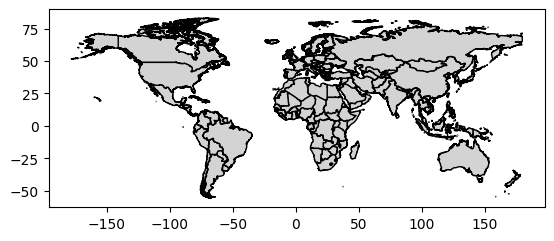

In [2]:
countries.plot(edgecolor='k',
               facecolor='lightgrey')

<GeoAxes: >

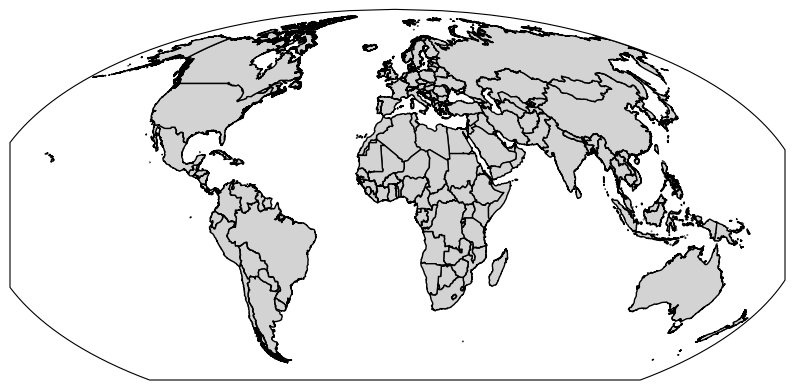

In [3]:
crs=ccrs.Mollweide()
fig=plt.figure(figsize=(10,5))
ax=plt.axes(projection=crs)
countries.to_crs(crs).plot(ax=ax,
                           edgecolor='k',
                           facecolor='lightgrey')

# Raster Data With Rasterio

In [4]:
url='u2018_clc2018_v2020_20u1-pt.tif'
clc=rio.open(url)
band=clc.read(1)
type(band)

numpy.ndarray

In [5]:
band.shape

(5662, 3404)

In [6]:
np.unique(band)

array([-128,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
         11,   12,   13,   14,   15,   16,   17,   18,   19,   20,   21,
         22,   23,   24,   25,   26,   27,   28,   29,   30,   31,   32,
         33,   35,   37,   38,   39,   40,   41,   42,   43,   44],
      dtype=int8)

In [7]:
clc.crs

CRS.from_wkt('PROJCS["ETRS89-extended / LAEA Europe",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4258"]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",52],PARAMETER["longitude_of_center",10],PARAMETER["false_easting",4321000],PARAMETER["false_northing",3210000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Northing",NORTH],AXIS["Easting",EAST],AUTHORITY["EPSG","3035"]]')

In [8]:
clc.bounds

BoundingBox(left=2635400.0, bottom=1732500.0, right=2975800.0, top=2298700.0)

In [9]:
clc.transform

Affine(100.0, 0.0, 2635400.0,
       0.0, -100.0, 2298700.0)

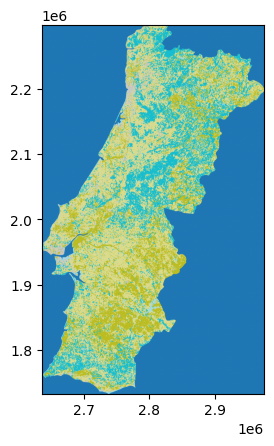

<Axes: >

In [10]:
show(band,transform=clc.transform,cmap='tab20')

In [11]:
url='data/gebco_2014_2d-pt.nc'
gebco=rio.open(url,driver='netcdf')
band=gebco.read(1)
np.unique(band)

array([-2898, -2862, -2856, ...,  1915,  1926,  1959],
      shape=(4184,), dtype=int16)

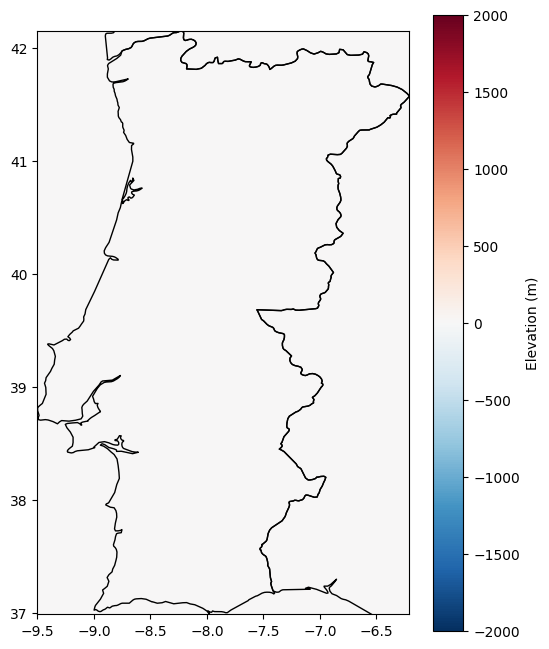

In [12]:
fig,ax=plt.subplots(figsize=(6,8))
countries.loc[['PT','ES']].plot(ax=ax,
                                color='none')
show(band,transform=gebco.transform,cmap='RdBu_r',ax=ax,vmin=-2000,vmax=2000)
plt.colorbar(ax.images[0],ax=ax,label='Elevation (m)')

# Land Eligibility Analysis With Atlite

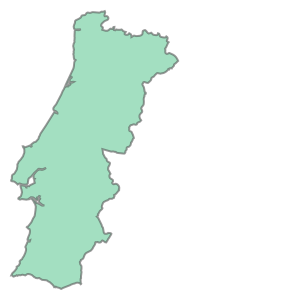

In [13]:
excluder=ExclusionContainer(crs=3035,
                            res=100)
url='natura2000_end2021-pt.gpkg'
excluder.add_geometry(url)
shape=countries.to_crs(excluder.crs).loc[['PT']].geometry
shape.iloc[0]

In [14]:
band,transform=shape_availability(shape,excluder)
band

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(5662, 3404))

In [15]:
band.any()

np.True_

In [16]:
transform

Affine(100.0, 0.0, 2635400.0,
       0.0, -100.0, 2298700.0)

<Axes: >

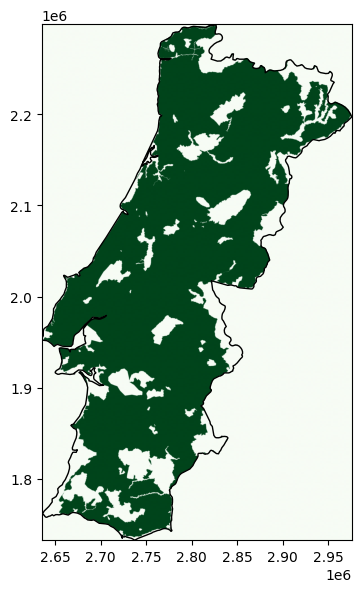

In [17]:
fig,ax=plt.subplots(figsize=(4,8))
shape.plot(ax=ax,
           color='none')
show(band,transform=transform,cmap='Greens',ax=ax)

In [18]:
eligible_cells=float(band.sum())
cell_area=float(excluder.res**2)
eligible_area=cell_area*eligible_cells
country_area=shape.geometry.area.iloc[0]
eligible_area/country_area*100

np.float64(79.65002907506347)

<Axes: >

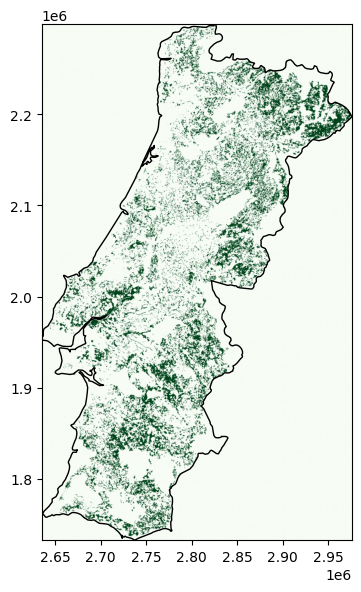

In [19]:
url='u2018_clc2018_v2020_20u1-pt.tif'
codes_to_exclude=[1,2,3,4,5,6]
excluder.add_raster(url,codes=codes_to_exclude,crs=3035,buffer=800,nodata=48)
codes_to_include=[12,13,18,19,20,21]
excluder.add_raster(url,codes=codes_to_include,crs=3035,invert=True,nodata=48)
band,transform=shape_availability(shape,excluder)
fig,ax=plt.subplots(figsize=(4,8))
shape.plot(ax=ax,
           color='none')
show(band,transform=transform,cmap='Greens',ax=ax)

# Spatial, Temporal Availability

In [20]:
cutout=atlite.Cutout('data/portugal-2013-01-era5.nc')
cutout

<Cutout "portugal-2013-01-era5">
 x = -9.90 ⟷ -6.00, dx = 0.30
 y = 36.00 ⟷ 42.90, dy = 0.30
 time = 2013-01-01 ⟷ 2013-02-01, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']

In [21]:
cutout.data

<xarray.Dataset> Size: 17MB
Dimensions:           (y: 24, x: 14, time: 768)
Coordinates:
  * y                 (y) float64 192B 36.0 36.3 36.6 36.9 ... 42.3 42.6 42.9
    lat               (y) float64 192B dask.array<chunksize=(24,), meta=np.ndarray>
  * x                 (x) float64 112B -9.9 -9.6 -9.3 -9.0 ... -6.6 -6.3 -6.0
    lon               (x) float64 112B dask.array<chunksize=(14,), meta=np.ndarray>
  * time              (time) datetime64[ns] 6kB 2013-01-01 ... 2013-02-01T23:...
Data variables: (12/13)
    height            (y, x) float32 1kB dask.array<chunksize=(24, 14), meta=np.ndarray>
    wnd100m           (time, y, x) float32 1MB dask.array<chunksize=(100, 24, 14), meta=np.ndarray>
    wnd_azimuth       (time, y, x) float32 1MB dask.array<chunksize=(100, 24, 14), meta=np.ndarray>
    roughness         (time, y, x) float32 1MB dask.array<chunksize=(100, 24, 14), meta=np.ndarray>
    influx_toa        (time, y, x) float32 1MB dask.array<chunksize=(100, 24, 14), meta=np.ndarray>
    influx_direct     (time, y, x) float32 1MB dask.array<chunksize=(100, 24, 14), meta=np.ndarray>
    ...                ...
    albedo            (time, y, x) float32 1MB dask.array<chunksize=(100, 24, 14), meta=np.ndarray>
    solar_altitude    (time, y, x) float64 2MB dask.array<chunksize=(100, 24, 14), meta=np.ndarray>
    solar_azimuth     (time, y, x) float64 2MB dask.array<chunksize=(100, 24, 14), meta=np.ndarray>
    temperature       (time, y, x) float64 2MB dask.array<chunksize=(100, 24, 14), meta=np.ndarray>
    soil temperature  (time, y, x) float64 2MB dask.array<chunksize=(100, 24, 14), meta=np.ndarray>
    runoff            (time, y, x) float32 1MB dask.array<chunksize=(100, 24, 14), meta=np.ndarray>
Attributes:
    module:             era5
    prepared_features:  ['height', 'runoff', 'temperature', 'wind', 'influx']
    chunksize_time:     100
    dx:                 0.3
    dy:                 0.3
    Conventions:        CF-1.6
    history:            2022-03-04 14:08:37 GMT by grib_to_netcdf-2.24.2: /op...

<Axes: >

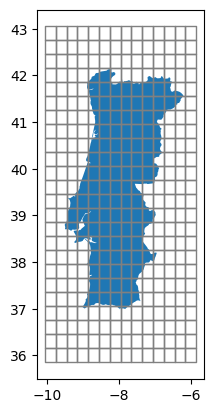

In [22]:
ax=shape.to_crs(4326).plot()
cutout.grid.plot(ax=ax,
                 edgecolor='grey',
                 color='None')

In [23]:
wnd100m=cutout.data.wnd100m.mean(dim='time')
wnd100m

<xarray.DataArray 'wnd100m' (y: 24, x: 14)> Size: 1kB
dask.array<mean_agg-aggregate, shape=(24, 14), dtype=float32, chunksize=(24, 14), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 192B 36.0 36.3 36.6 36.9 37.2 ... 42.0 42.3 42.6 42.9
    lat      (y) float64 192B dask.array<chunksize=(24,), meta=np.ndarray>
  * x        (x) float64 112B -9.9 -9.6 -9.3 -9.0 -8.7 ... -6.9 -6.6 -6.3 -6.0
    lon      (x) float64 112B dask.array<chunksize=(14,), meta=np.ndarray>
Attributes:
    units:      m s**-1
    long_name:  100 metre wind speed
    module:     era5
    feature:    wind

<GeoAxes: xlabel='x', ylabel='y'>

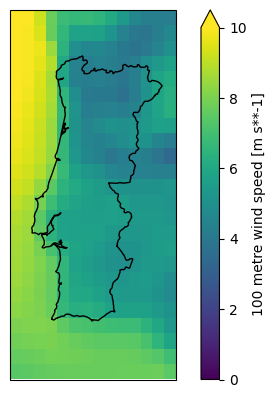

In [24]:
ax=plt.axes(projection=ccrs.PlateCarree())
wnd100m.plot(ax=ax,
             vmin=0,
             vmax=10)
shape.to_crs(4326).plot(ax=ax,
                        edgecolor='k',
                        color='none')

<GeoAxes: xlabel='x', ylabel='y'>

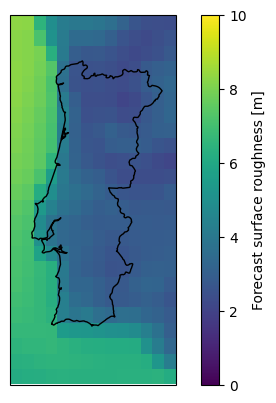

In [25]:
z_r=cutout.data.roughness
wnd100m=cutout.data.wnd100m
wnd10m=wnd100m*np.log(10/z_r)/np.log(100/z_r)
ax=plt.axes(projection=ccrs.PlateCarree())
wnd10m.mean(dim='time').plot(ax=ax,
                             vmin=0,
                             vmax=10)
shape.to_crs(4326).plot(ax=ax,
                        edgecolor='k',
                        color='none')

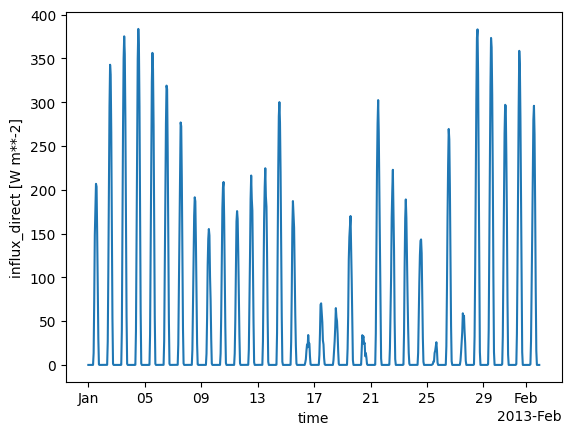

In [26]:
cutout.data.mean(dim=['x','y']).influx_direct.plot()

In [27]:
A=cutout.availabilitymatrix(shape,excluder)
A.coords

Coordinates:
  * name     (name) object 8B 'PT'
  * y        (y) float64 192B 36.0 36.3 36.6 36.9 37.2 ... 42.0 42.3 42.6 42.9
  * x        (x) float64 112B -9.9 -9.6 -9.3 -9.0 -8.7 ... -6.9 -6.6 -6.3 -6.0

<Axes: title={'center': 'name = PT'}, xlabel='x', ylabel='y'>

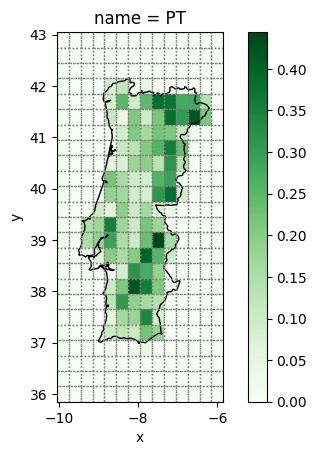

In [28]:
fig,ax=plt.subplots()
A.sel(name='PT').plot(cmap='Greens')
shape.to_crs(4326).plot(ax=ax,
                        edgecolor='k',
                        color='none')
cutout.grid.plot(ax=ax,
                 color='none',
                 edgecolor='grey',
                 ls=':')

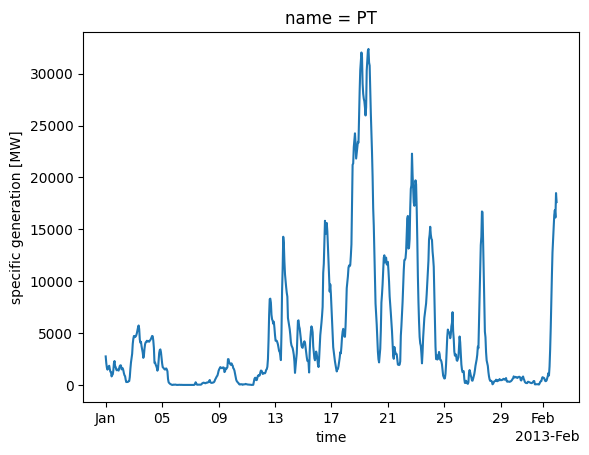

In [29]:
cap_per_sqkm=2
area=cutout.grid.set_index(['y','x']).to_crs(3035).area/1e6
area=xr.DataArray(area,dims=('spatial'))
capacity_matrix=A.stack(spatial=['y','x'])*area*cap_per_sqkm
wind=cutout.wind(matrix=capacity_matrix,
                 turbine='Vestas_V90_3MW',
                 index=shape.index,
                 add_cutout_windspeed=True)
wind.plot()

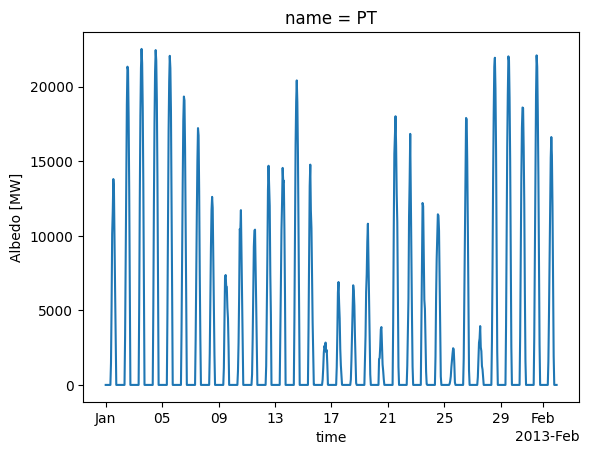

In [30]:
pv=cutout.pv(panel='CSi',
             orientation={'slope':30,
                          'azimuth':180},
             matrix=capacity_matrix,
             index=shape.index)
pv.plot()

## Solar PV Orientation Sensitivities Sensitivities

In [31]:
url='data/country_shapes_reduced.geojson'
countries=gpd.read_file(url).set_index('name')
shapes=countries.loc[['PT']].geometry
cutout.pv(panel='CSi',
          orientation={'slope':30,
                       'azimuth':180},
          shapes=shapes,
          per_unit=True)

<xarray.DataArray (time: 768, name: 1)> Size: 6kB
array([[0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [4.23259202e-02],
       [1.54659473e-01],
       [2.96705202e-01],
       [3.54283778e-01],
       [4.23966612e-01],
       [4.00369283e-01],
       [3.08207520e-01],
       [1.92481709e-01],
       [8.77487256e-02],
       [0.00000000e+00],
       [0.00000000e+00],
...
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [4.97159643e-02],
       [1.44374187e-01],
       [2.51331753e-01],
       [3.70007494e-01],
       [4.49929139e-01],
       [4.70099805e-01],
       [4.42353101e-01],
       [3.43244557e-01],
       [1.89051756e-01],
       [5.64463039e-02],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00]])
Coordinates:
  * time     (time) datetime64[ns] 6kB 2013-01-01 ... 2013-02-01T23:00:00
  * name     (name) object 8B 'PT'
Attributes:
    time shift:  -1 days +23:30:00
    module:      era5
    feature:     influx
    long_name:   Albedo
    units:       p.u.

In [32]:
kwargs=dict(panel='CSi',
            shapes=shapes,
            per_unit=True)
pv_orientation={}
for slope in range(0,100,10):
    print(f'Slope: {slope}°')
    pv_orientation[slope]=(cutout.pv(orientation=dict(slope=slope,
                                                      azimuth=180),**kwargs).to_pandas().squeeze())

Slope: 0°
Slope: 10°
Slope: 20°
Slope: 30°
Slope: 40°
Slope: 50°
Slope: 60°
Slope: 70°
Slope: 80°
Slope: 90°


The optimal slope's 60°.


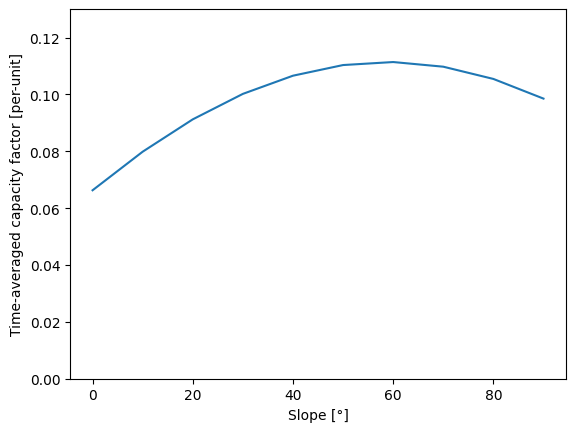

In [33]:
df=pd.DataFrame(pv_orientation)
ax=df.mean().plot(ylabel='Time-averaged capacity factor [per-unit]',
                  xlabel='Slope [°]')
ax.set_ylim(0,.13)
best=df.mean().idxmax()
print(f"The optimal slope's {best:.0f}°.")

In [34]:
pv_azimuth={}
for angle in [0,90,180,270]:
    print(f'Azimuth: {angle}°')
    pv_azimuth[angle]=(cutout.pv(orientation=dict(slope=30,
                                                  azimuth=angle),**kwargs).to_pandas().squeeze())

Azimuth: 0°
Azimuth: 90°
Azimuth: 180°
Azimuth: 270°


<Axes: xlabel='time', ylabel='Capacity factor [per-unit]'>

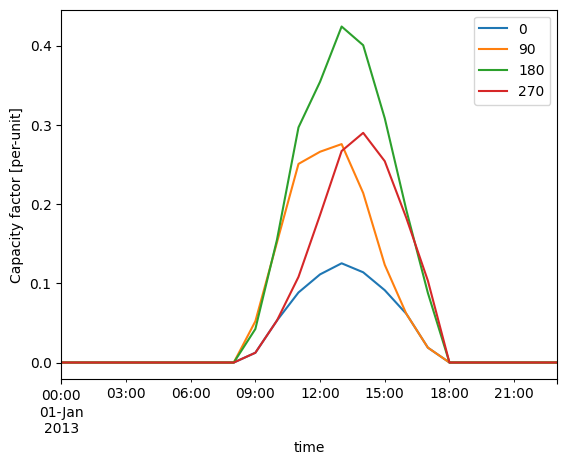

In [35]:
df=pd.DataFrame(pv_azimuth)
df.loc['2013-01-01'].plot(ylabel='Capacity factor [per-unit]')

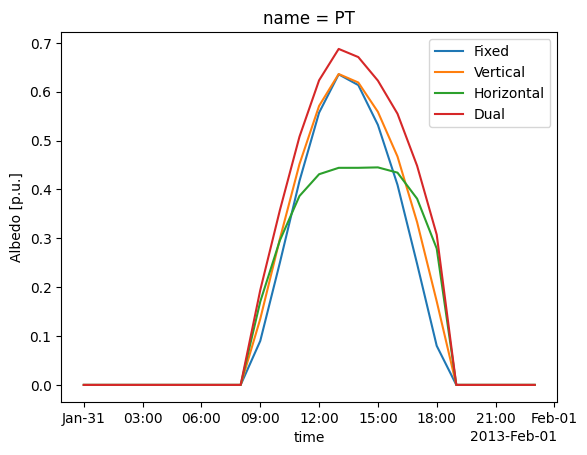

In [36]:
kwargs=dict(panel='CSi',
            orientation={'slope':30,
                         'azimuth':180},
            shapes=shapes,
            per_unit=True)
pv=cutout.pv(**kwargs)
pv_h=cutout.pv(tracking='horizontal',**kwargs)
pv_v=cutout.pv(tracking='vertical',**kwargs)
pv_d=cutout.pv(tracking='dual',**kwargs)
DAY='2013-01-31'
fig,ax=plt.subplots()
pv.loc[DAY].plot(ax=ax,
                 label='Fixed')
pv_v.loc[DAY].plot(ax=ax,
                   label='Vertical')
pv_h.loc[DAY].plot(ax=ax,
                   label='Horizontal')
pv_d.loc[DAY].plot(ax=ax,
                   label='Dual')
plt.legend()